In [1]:
import numpy as np
import pandas as pd

from scformer.utils import *
from scformer.model import *
from warnings import filterwarnings
import random
import os
import torch
import torch.cuda as cuda
from scipy import sparse
import scanpy as sc
import anndata as ad
from scipy.sparse import csr_matrix

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [2]:
adata_151673 = sc.read_10x_mtx('data/DLPFC/151673/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
metadata = pd.read_csv('data/DLPFC/151673/metadata.csv')
adata_151673.obs = metadata
adata_151673.var_names_make_unique()
adata_151673

AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial'
    var: 'gene_ids', 'feature_types'

In [3]:
adata_151674 = sc.read_10x_mtx('data/DLPFC/151672/filtered_feature_bc_matrix', var_names='gene_symbols', cache=True)
metadata = pd.read_csv('data/DLPFC/151672/metadata.tsv')
adata_151674.obs = metadata
adata_151674.var_names_make_unique()
adata_151674

AnnData object with n_obs × n_vars = 4015 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial'
    var: 'gene_ids', 'feature_types'

In [4]:
adata_151673.obs['batch'] = 'batch_1'
adata_151674.obs['batch'] = 'batch_2'
adata = sc.concat([adata_151673, adata_151674], join='outer', label='batch', keys=['batch1', 'batch2'])
adata.obs['original_index'] = adata.obs.index
# 将索引重置为从 0 到 n_obs - 1 的整数索引
adata.obs.index = np.arange(adata.n_obs)
adata.obs.index = adata.obs.index.astype(str)  # 转换为字符串以避免潜在的问题
adata

AnnData object with n_obs × n_vars = 7654 × 33538
    obs: 'key', 'ground_truth', 'SpatialDE_PCA', 'SpatialDE_pool_PCA', 'HVG_PCA', 'pseudobulk_PCA', 'markers_PCA', 'SpatialDE_UMAP', 'SpatialDE_pool_UMAP', 'HVG_UMAP', 'pseudobulk_UMAP', 'markers_UMAP', 'SpatialDE_PCA_spatial', 'SpatialDE_pool_PCA_spatial', 'HVG_PCA_spatial', 'pseudobulk_PCA_spatial', 'markers_PCA_spatial', 'SpatialDE_UMAP_spatial', 'SpatialDE_pool_UMAP_spatial', 'HVG_UMAP_spatial', 'pseudobulk_UMAP_spatial', 'markers_UMAP_spatial', 'batch', 'original_index'

In [5]:
adata.raw = adata.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, zero_center=True)
adata.X = csr_matrix(adata.X)

In [6]:
RNA_matrix = adata.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 300

In [7]:
initial_pre = initial_clustering(adata.raw.X)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size)
n_batch = len(indices)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
正在从磁盘加载处理后的数据...


In [8]:
class NDR_1(nn.Module):
    def __init__(self, RNA_matrix, indices, ini_p1, n_hid, n_heads,
                 n_layers, labsm, lr, wd, device, num_types=2, num_relations=2, epochs=1, loss_contrastive_weight=0.01):
        super(NDR_1, self).__init__()
        self.RNA_matrix = RNA_matrix
        self.indices = indices
        self.ini_p1 = ini_p1
        self.in_dim = [RNA_matrix.shape[0], RNA_matrix.shape[1]]  # 仅包含基因和细胞的维度
        self.n_hid = n_hid
        self.num_types = num_types  # 2 种类型：细胞和基因
        self.num_relations = num_relations  # 2 种关系：基因到细胞和细胞到基因
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.labsm = labsm
        self.lr = lr
        self.wd = wd
        self.device = device
        self.epochs = epochs
        self.loss_contrastive_weight = loss_contrastive_weight  # 新增超参数

        # 标签平滑
        self.LabSm = LabelSmoothing(self.labsm)

        # GNN 模型
        self.gnn = GNN_from_raw(in_dim=self.in_dim,
                                n_hid=self.n_hid,
                                num_types=self.num_types,
                                num_relations=self.num_relations,
                                n_heads=self.n_heads,
                                n_layers=self.n_layers,
                                dropout=0.3).to(self.device)

        # 优化器和学习率调度器
        self.optimizer = torch.optim.AdamW(self.gnn.parameters(), lr=self.lr, weight_decay=self.wd)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, 'min', factor=0.5, patience=5,
                                                                    verbose=True)

    def supervised_contrastive_loss(self, features, labels, batch_labels=None, temperature=0.07):
        """
        Compute supervised contrastive loss with batch labels.

        Args:
            features: tensor of shape [batch_size, embedding_dim]
            labels: tensor of shape [batch_size]
            batch_labels: tensor of shape [batch_size], indicating the batch assignments (optional)
            temperature: a float scalar temperature

        Returns:
            loss: a scalar loss value
        """
        # Normalize features
        features = F.normalize(features, dim=1)
        batch_size = features.shape[0]

        epsilon = 1e-10  # 防止除以零或对数零

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / temperature

        # Clamp similarity_matrix to prevent large values
        max_sim = 50  # 可以根据需要调整
        min_sim = -50
        similarity_matrix = torch.clamp(similarity_matrix, min=min_sim, max=max_sim)

        # Create masks
        labels = labels.contiguous().view(-1, 1)
        if labels.shape[0] != batch_size:
            raise ValueError('Number of labels does not match number of features')

        # Positive mask: labels match
        label_eq = torch.eq(labels, labels.T).float().to(features.device)

        # If batch labels are provided, ensure positives come from different batches
        if batch_labels is not None:
            batch_labels = batch_labels.contiguous().view(-1, 1)
            batch_neq = (~torch.eq(batch_labels, batch_labels.T)).float().to(features.device)
            mask = label_eq * batch_neq
        else:
            # If no batch labels, use label matching only
            mask = label_eq

        # Remove self-contrast cases
        logits_mask = torch.ones_like(mask) - torch.eye(batch_size).to(features.device)
        mask = mask * logits_mask

        # Compute log_prob
        exp_sim = torch.exp(similarity_matrix) * logits_mask
        exp_sim_sum = exp_sim.sum(1, keepdim=True) + epsilon  # 添加 epsilon 防止 log(0)
        log_prob = similarity_matrix - torch.log(exp_sim_sum)

        # Compute mean of log-likelihood over positive
        mask_sum = mask.sum(1)
        # 避免除以零
        mean_log_prob_pos = torch.zeros_like(mask_sum)
        non_zero_mask = mask_sum > 0
        mean_log_prob_pos[non_zero_mask] = ((mask * log_prob).sum(1)[non_zero_mask]) / mask_sum[non_zero_mask]

        # Loss
        loss = -mean_log_prob_pos
        # Avoid NaNs
        loss = loss[non_zero_mask].mean()
        return loss

    def train_model(self, n_batch, batch_labels_list=None):
        """
        Args:
            n_batch: number of batches
            batch_labels_list: (optional) a list where each element is a tensor of batch labels for the cells in that batch
        """
        print('The training process for the NodeDimensionReduction model has started. Please wait.')
        h_final = None  # 用于存储最后一个 h
        for epoch in tqdm(range(self.epochs), desc="Epochs"):
            for batch_id in range(n_batch):
                # 获取当前批次的基因和细胞索引
                gene_index = self.indices[batch_id]['gene_index']
                cell_index = self.indices[batch_id]['cell_index']

                # 提取基因和细胞的特征
                gene_feature = self.RNA_matrix[list(gene_index), :]
                cell_feature = self.RNA_matrix[:, list(cell_index)].T

                # 转换为张量并移动到设备上
                gene_feature = torch.tensor(gene_feature.todense(), dtype=torch.float32).to(self.device)
                cell_feature = torch.tensor(cell_feature.todense(), dtype=torch.float32).to(self.device)

                # 构建节点特征列表（细胞和基因）
                node_feature = [cell_feature, gene_feature]

                # 构建基因-细胞子图的邻接矩阵
                gene_cell_sub = self.RNA_matrix[list(gene_index), :][:, list(cell_index)]

                # 构建基因到细胞的边索引
                gene_to_cell_src = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))  # 基因索引从 len(cell_index) 开始
                gene_to_cell_dst = list(np.nonzero(gene_cell_sub)[1])

                # 构建细胞到基因的边索引
                cell_to_gene_src = list(np.nonzero(gene_cell_sub)[1])
                cell_to_gene_dst = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))  # 基因索引

                # 合并边索引
                edge_index = torch.LongTensor([
                    gene_to_cell_src + cell_to_gene_src,  # 源节点
                    gene_to_cell_dst + cell_to_gene_dst  # 目标节点
                ]).to(self.device)

                # 定义节点类型：0 代表细胞，1 代表基因
                node_type = torch.LongTensor(
                    np.array(
                        list(np.zeros(len(cell_index))) + list(np.ones(len(gene_index)))
                    )
                ).to(self.device)

                # 定义边类型：0 代表基因到细胞，1 代表细胞到基因
                edge_type_gene_to_cell = np.zeros(len(gene_to_cell_src), dtype=int)
                edge_type_cell_to_gene = np.ones(len(cell_to_gene_src), dtype=int)
                edge_type = torch.LongTensor(
                    np.concatenate([edge_type_gene_to_cell, edge_type_cell_to_gene])
                ).to(self.device)

                # 获取标签
                l = torch.LongTensor(np.array(self.ini_p1)[cell_index]).to(self.device)

                # 获取批次标签
                # batch_labels = batch_labels_list[batch_id]
                # batch_labels = torch.LongTensor(batch_labels).to(self.device)
                if batch_labels_list is not None:
                    batch_labels = batch_labels_list[batch_id]
                    batch_labels = torch.LongTensor(batch_labels).to(self.device)
                else:
                    batch_labels = None

                # ==============
                # print("node_feature:", node_feature)
                # print("node_type:", node_type)
                # print("edge_index:", edge_index)
                # print("edge_type:", edge_type)
                #
                # node_rep = self.gnn.forward(node_feature, node_type, edge_index, edge_type)
                # if torch.isnan(node_rep).any():
                #     print("node_rep contains NaN values.")
                # 可以在这里中断或返回，避免继续计算
                # ===============

                # 前向传播
                node_rep = self.gnn.forward(node_feature, node_type, edge_index, edge_type).to(self.device)
                cell_emb = node_rep[node_type == 0]
                gene_emb = node_rep[node_type == 1]

                # 解码器：基因与细胞的关系
                decoder_gene_to_cell = torch.mm(gene_emb, cell_emb.t())
                decoder_cell_to_gene = torch.mm(cell_emb, gene_emb.t())

                # 构建目标矩阵
                gene_cell_sub_tensor = torch.tensor(gene_cell_sub.todense(), dtype=torch.float32).to(self.device)

                # 计算基因到细胞的 KL 散度损失
                logp_x1 = F.log_softmax(decoder_gene_to_cell, dim=-1)
                p_y1 = F.softmax(gene_cell_sub_tensor, dim=-1)
                loss_kl1 = F.kl_div(logp_x1, p_y1, reduction='mean')

                # 计算细胞到基因的 KL 散度损失
                logp_x2 = F.log_softmax(decoder_cell_to_gene, dim=-1)
                p_y2 = F.softmax(gene_cell_sub_tensor.t(), dim=-1)
                loss_kl2 = F.kl_div(logp_x2, p_y2, reduction='mean')

                # 总的 KL 散度损失
                loss_kl = loss_kl1 + loss_kl2

                # 聚类损失
                loss_cluster = self.LabSm(cell_emb, l)

                # 余弦相似度损失
                lll = 0
                g = l.tolist()
                unique_labels = set(g)
                for label in unique_labels:
                    mask = np.array(g) == label
                    h = cell_emb[mask]
                    if h.size(0) > 1:
                        # 计算细胞间的余弦相似度
                        similarity = F.cosine_similarity(h.unsqueeze(1), h.unsqueeze(0), dim=-1)
                        lll += similarity.mean()
                        h_final = h  # 更新 h_final 为当前标签的 h

                # 对比学习损失
                loss_contrastive = self.supervised_contrastive_loss(cell_emb, l, batch_labels)

                # 总损失
                loss = loss_cluster + loss_kl + self.loss_contrastive_weight * loss_contrastive - lll
                # loss = loss_cluster + loss_kl - lll

                # 反向传播和优化
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

        print('The training for the NodeDimensionReduction model has been completed.')
        return self.gnn, cell_emb, gene_emb, h_final  # 返回 h_final

    def save_model(self, file_path):
        """保存训练好的模型"""
        torch.save(self.gnn.state_dict(), file_path)

    def load_model(self, file_path):
        """加载保存的模型

        Args:
            file_path (str): 模型文件的路径
        """
        # 加载模型的状态字典
        state_dict = torch.load(file_path, map_location=self.device)
        # 将状态字典加载到 GNN 模型中
        self.gnn.load_state_dict(state_dict)
        # 将模型移动到指定的设备
        self.gnn.to(self.device)
        # 设置模型为评估模式（如果需要进行推理）
        self.gnn.eval()
        print(f"Model loaded successfully from {file_path}.")


def HGT_pre(RNA_matrix, gnn, indices, device, cell_size=30):
    """
    Use the trained ScFormer model for prediction.

    :param RNA_matrix: Gene expression matrix (scipy.sparse or similar format)
    :param gnn: Trained ScFormer model
    :param indices: List of batch indices, each containing 'gene_index' and 'cell_index'
    :param device: Computation device (e.g., torch.device('cuda') or torch.device('cpu'))
    :param cell_size: Number of cells to process in each batch
    :return: Dictionary containing predicted labels (if applicable) and cell embeddings
    """
    n_cells = RNA_matrix.shape[1]
    n_batch = len(indices)
    embedding_dim = gnn.n_hid  # Assuming the hidden dimension is the embedding dimension

    # Initialize an array to store cell embeddings
    cell_embedding = np.zeros((n_cells, embedding_dim))

    ScFormer_result = {}
    with torch.no_grad():
        for batch_id in tqdm(range(n_batch), desc="Prediction Batches"):
            gene_index = indices[batch_id]['gene_index']
            cell_index = indices[batch_id]['cell_index']

            # Extract features for genes and cells
            gene_feature = RNA_matrix[list(gene_index), :]
            cell_feature = RNA_matrix[:, list(cell_index)].T

            # Convert to tensors and move to device
            gene_feature = torch.tensor(gene_feature.todense(), dtype=torch.float32).to(device)
            cell_feature = torch.tensor(cell_feature.todense(), dtype=torch.float32).to(device)

            # Build node features list (cells and genes)
            node_feature = [cell_feature, gene_feature]

            # Build gene-cell subgraph adjacency matrix
            gene_cell_sub = RNA_matrix[list(gene_index), :][:, list(cell_index)]

            # Build edge indices
            gene_to_cell_src = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            gene_to_cell_dst = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_src = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_dst = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            edge_index = torch.LongTensor([
                gene_to_cell_src + cell_to_gene_src,
                gene_to_cell_dst + cell_to_gene_dst
            ]).to(device)

            # Define node types: 0 for cells, 1 for genes
            node_type = torch.LongTensor(
                np.array(
                    list(np.zeros(len(cell_index), dtype=int)) + list(np.ones(len(gene_index), dtype=int))
                )
            ).to(device)

            # Define edge types: 0 for gene to cell, 1 for cell to gene
            edge_type_gene_to_cell = np.zeros(len(gene_to_cell_src), dtype=int)
            edge_type_cell_to_gene = np.ones(len(cell_to_gene_src), dtype=int)
            edge_type = torch.LongTensor(
                np.concatenate([edge_type_gene_to_cell, edge_type_cell_to_gene])
            ).to(device)

            # Forward pass through the GNN model
            node_rep = gnn(node_feature, node_type, edge_index, edge_type)
            cell_emb = node_rep[node_type == 0]
            # gene_emb = node_rep[node_type == 1]  # If needed elsewhere

            # Store cell embeddings in the correct positions
            cell_embedding[cell_index] = cell_emb.cpu().numpy()

    # Since we might not have labels during prediction, we can return embeddings
    ScFormer_result = {'cell_embedding': cell_embedding}
    return ScFormer_result

In [9]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
in_dim = [RNA_matrix.shape[0], RNA_matrix.shape[1]]
n_hid = 104
num_types = 2
num_relations = 2
n_heads = 8
n_layers = 3
dropout = 0.3

# 创建新的 gnn 实例
gnn = GNN_from_raw(in_dim=in_dim,
                   n_hid=n_hid,
                   num_types=num_types,
                   num_relations=num_relations,
                   n_heads=n_heads,
                   n_layers=n_layers,
                   dropout=dropout).to(device)

# 加载模型状态字典
model_file_path = 'new_model_1.pth'
state_dict = torch.load(model_file_path, map_location=device)
gnn.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
gnn.eval()

GNN_from_raw(
  (gcs): ModuleList(
    (0-2): 3 x GeneralConv(
      (base_conv): HGTConv(in_dim=104, out_dim=104, num_types=2, num_types=2)
    )
  )
  (adapt_ws): ModuleList(
    (0-1): 2 x Linear(in_features=256, out_features=104, bias=True)
  )
  (drop): Dropout(p=0.3, inplace=False)
  (embedding1): ModuleList(
    (0): Linear(in_features=33538, out_features=256, bias=True)
    (1): Linear(in_features=7654, out_features=256, bias=True)
  )
)

In [11]:
ScFormer_result = HGT_pre(RNA_matrix, gnn, indices, device, cell_size=cell_size)

Prediction Batches: 100%|██████████| 26/26 [02:50<00:00,  6.54s/it]


In [13]:
# ScFormer_result = ScFormer_pred(RNA_matrix, gnn=ScFormer_gnn, indices=indices,
#                                 nodes_id=Node_Ids, device=device, cell_size=cell_size)

# Save numpy arrays to files
output_file = 'data/DLPFC/output/different_samples_1'
os.makedirs(output_file, exist_ok=True)
np.save(output_file + "/Node_Ids.npy", Node_Ids)
# np.save(output_file + "/pred.npy", ScFormer_result['pred_label'])
np.save(output_file + "/cell_embedding.npy", ScFormer_result['cell_embedding'])

         Falling back to preprocessing with `sc.pp.pca` and default params.


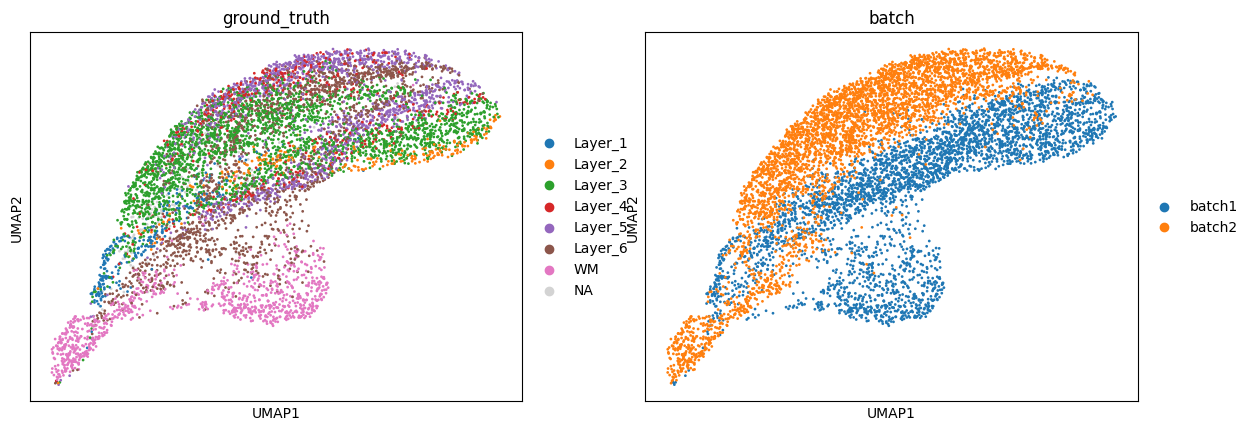

In [5]:
# 后续分析和可视化
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

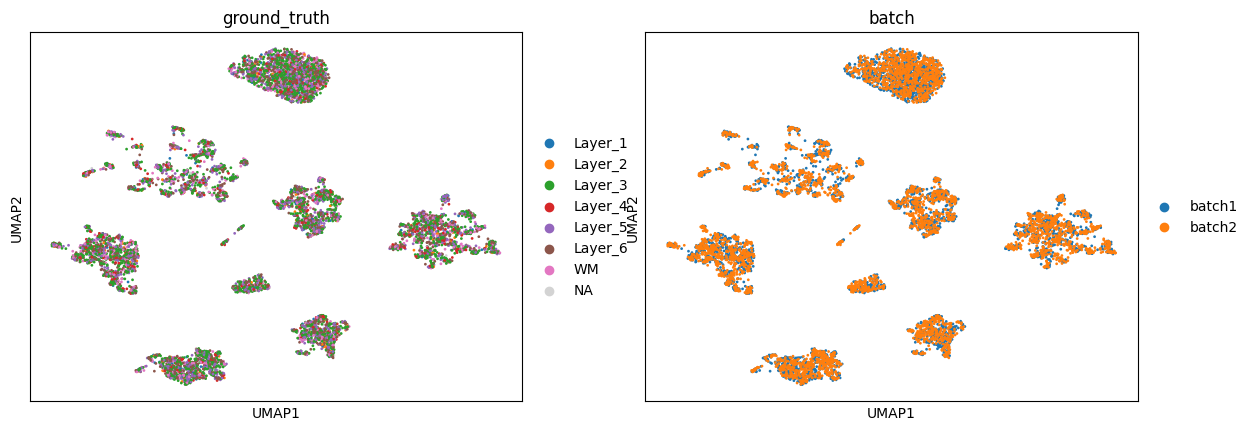

In [15]:
adata.obsm['cell_emb'] = ScFormer_result['cell_embedding']

# 后续分析和可视化
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

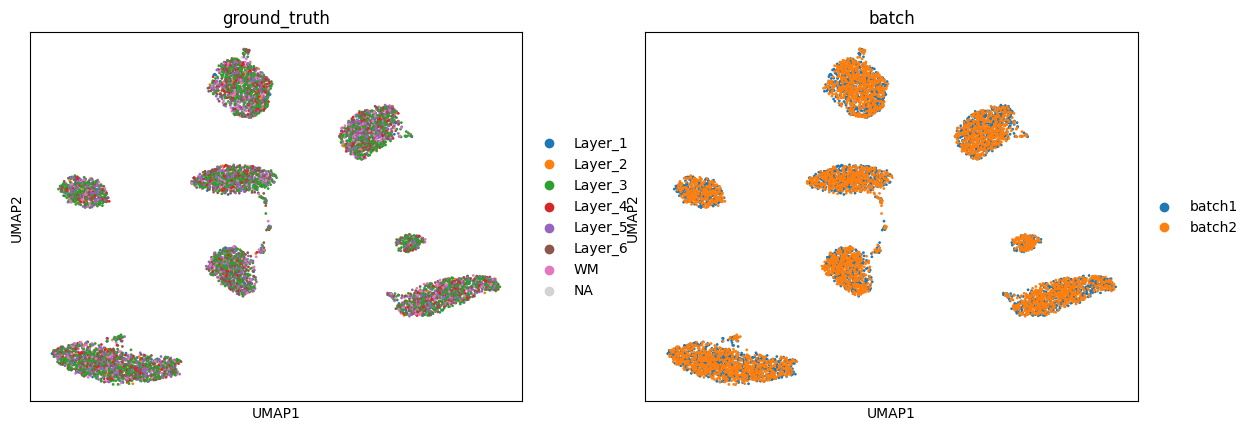

In [9]:
Node_Ids = np.load('data/DLPFC/output/different_samples_1/Node_Ids.npy')
# Node_Ids
cell_emb = np.load('data/DLPFC/output/different_samples_1/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values
# pred = np.load('data/DLPFC/output/different_samples/pred.npy')
# pred_ = pd.DataFrame(pred, index=Node_Ids)
# pred_sorted = pred_.sort_index()
# adata.obs['pre'] = pred_sorted.values
# adata.obs['pre'] = adata.obs['pre'].astype('category')
# adata
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

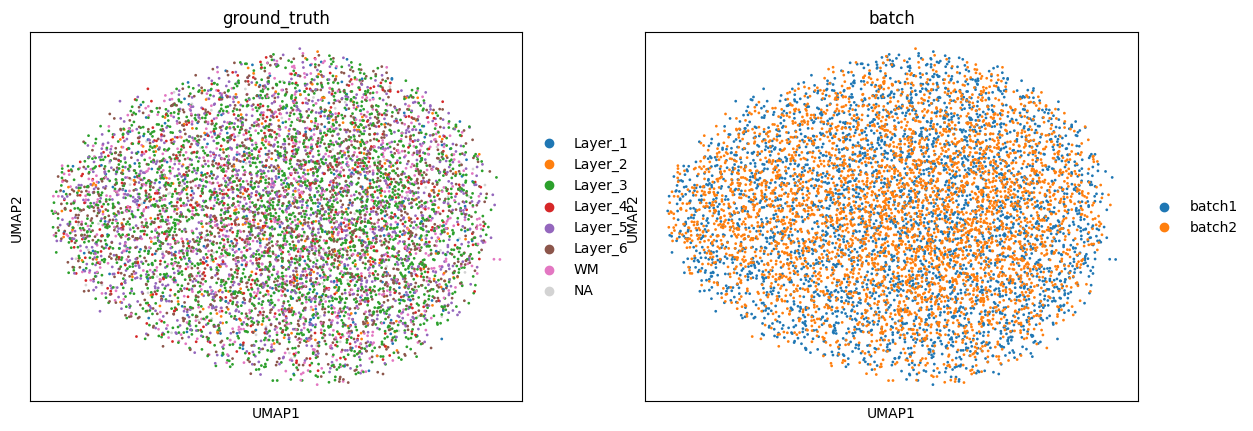

In [7]:
Node_Ids = np.load('data/DLPFC/output/different_samples_4/Node_Ids.npy')
# Node_Ids
cell_emb = np.load('data/DLPFC/output/different_samples_4/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values
# pred = np.load('data/DLPFC/output/different_samples/pred.npy')
# pred_ = pd.DataFrame(pred, index=Node_Ids)
# pred_sorted = pred_.sort_index()
# adata.obs['pre'] = pred_sorted.values
# adata.obs['pre'] = adata.obs['pre'].astype('category')
# adata
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

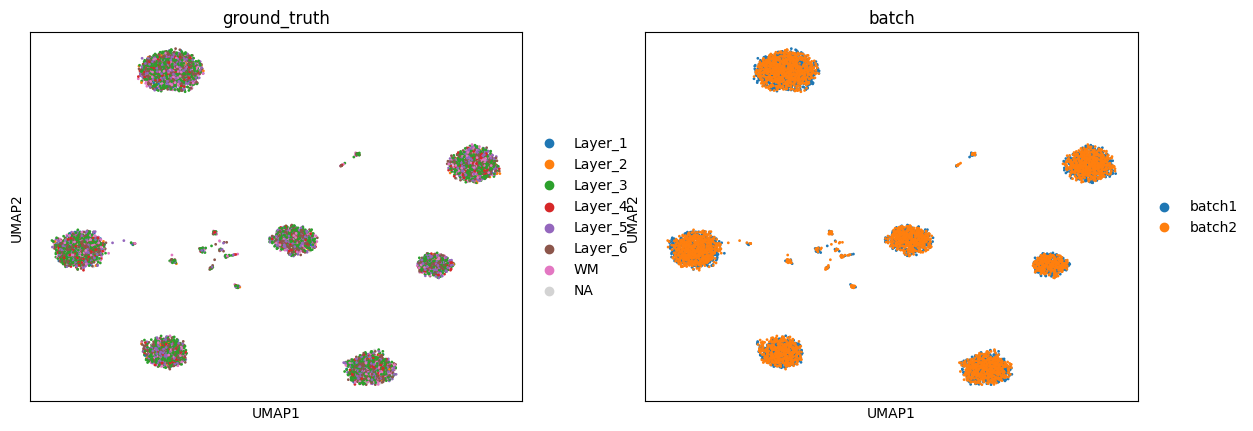

In [5]:
Node_Ids = np.load('data/DLPFC/output/different_samples_2/Node_Ids.npy')
# Node_Ids
cell_emb = np.load('data/DLPFC/output/different_samples_2/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values
# pred = np.load('data/DLPFC/output/different_samples/pred.npy')
# pred_ = pd.DataFrame(pred, index=Node_Ids)
# pred_sorted = pred_.sort_index()
# adata.obs['pre'] = pred_sorted.values
# adata.obs['pre'] = adata.obs['pre'].astype('category')
# adata
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

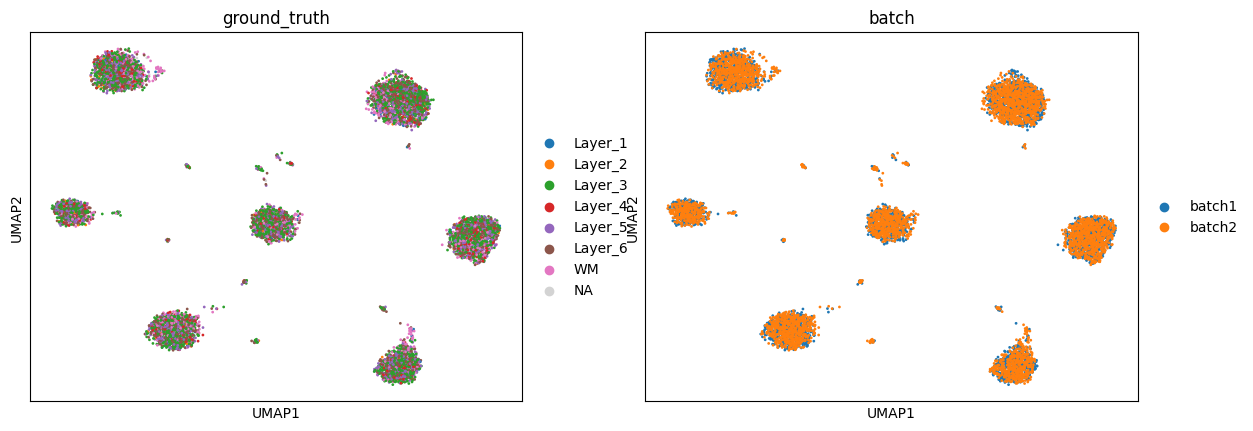

In [8]:
Node_Ids = np.load('data/DLPFC/output/different_samples_3/Node_Ids.npy')
# Node_Ids
cell_emb = np.load('data/DLPFC/output/different_samples_3/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=Node_Ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm['cell_emb'] = cell_emb_sorted.values
# pred = np.load('data/DLPFC/output/different_samples/pred.npy')
# pred_ = pd.DataFrame(pred, index=Node_Ids)
# pred_sorted = pred_.sort_index()
# adata.obs['pre'] = pred_sorted.values
# adata.obs['pre'] = adata.obs['pre'].astype('category')
# adata
adata.var_names_make_unique()
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep='cell_emb')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'batch'], show=True)

In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# adata.var['mt'] = adata.var_names.str.startswith('MT-')
# sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
# sc.pl.violin(adata, ['n_genes', 'n_counts', 'percent_mt'], jitter=0.4)

# 标准化和识别高度变异基因
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
# sc.pp.highly_variable_genes(adata_ESCA_train, min_mean=0.0125, max_mean=3, min_disp=0.5)
# adata = adata[:, adata.var['highly_variable']]
# sc.pl.highly_variable_genes(adata_ESCA_train)

# PCA
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
# sc.pl.pca_variance_ratio(adata_ESCA_train, log=True, n_pcs=50)

# 邻接图
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

# UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color=['ground_truth', 'pre', 'batch'])

In [ ]:
sc.tl.leiden(adata)  # 或者使用 sc.tl.louvain(adata)
sc.pl.umap(adata, color=['leiden'])

In [ ]:
import harmonypy as hm

# 使用Harmony进行批次校正
ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, 'batch')
adata.obsm['X_pca_harmony'] = ho.Z_corr.T  # 将校正后的PCA结果保存

# 使用校正后的PCA进行邻居计算
sc.pp.neighbors(adata, use_rep='X_pca_harmony')

# 后续聚类和可视化
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=['batch', 'leiden'])

In [ ]:
sc.pl.umap(adata, color=['ground_truth', 'pre'])

In [2]:
gene_cell = sparse.load_npz('data/example/RNA.npz')
gene_names = pd.DataFrame(np.load('data/example/gene_name.npy', allow_pickle=True))
true_label = np.load('data/example/label500.npy', allow_pickle=True)

gene_cell.obs_names = gene_names[0]

RNA_matrix = gene_cell

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

In [3]:
initial_pre = initial_clustering(RNA_matrix)
cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix)
n_batch = len(indices)

In [4]:
device = torch.device("cuda" if cuda.is_available() else "cpu")
node_model = NDR_1(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

In [5]:
def HGT_pre(RNA_matrix, gnn, indices, device, cell_size=30):
    """
    Use the trained ScFormer model for prediction.

    :param RNA_matrix: Gene expression matrix (scipy.sparse or similar format)
    :param gnn: Trained ScFormer model
    :param indices: List of batch indices, each containing 'gene_index' and 'cell_index'
    :param device: Computation device (e.g., torch.device('cuda') or torch.device('cpu'))
    :param cell_size: Number of cells to process in each batch
    :return: Dictionary containing predicted labels (if applicable) and cell embeddings
    """
    n_cells = RNA_matrix.shape[1]
    n_batch = math.ceil(n_cells / cell_size)
    embedding = []
    ScFormer_result = {}
    with torch.no_grad():
        for batch_id in tqdm(range(n_batch), desc="Prediction Batches"):
            gene_index = indices[batch_id]['gene_index']
            cell_index = indices[batch_id]['cell_index']

            # Extract features for genes and cells
            gene_feature = RNA_matrix[list(gene_index), :]
            cell_feature = RNA_matrix[:, list(cell_index)].T

            # Convert to tensors and move to device
            gene_feature = torch.tensor(gene_feature.todense(), dtype=torch.float32).to(device)
            cell_feature = torch.tensor(cell_feature.todense(), dtype=torch.float32).to(device)

            # Build node features list (cells and genes)
            node_feature = [cell_feature, gene_feature]

            # Build gene-cell subgraph adjacency matrix
            gene_cell_sub = RNA_matrix[list(gene_index), :][:, list(cell_index)]

            # Build edge indices
            gene_to_cell_src = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            gene_to_cell_dst = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_src = list(np.nonzero(gene_cell_sub)[1])
            cell_to_gene_dst = list(np.nonzero(gene_cell_sub)[0] + len(cell_index))
            edge_index = torch.LongTensor([
                gene_to_cell_src + cell_to_gene_src,
                gene_to_cell_dst + cell_to_gene_dst
            ]).to(device)

            # Define node types: 0 for cells, 1 for genes
            node_type = torch.LongTensor(
                np.array(
                    list(np.zeros(len(cell_index), dtype=int)) + list(np.ones(len(gene_index), dtype=int))
                )
            ).to(device)

            # Define edge types: 0 for gene to cell, 1 for cell to gene
            edge_type_gene_to_cell = np.zeros(len(gene_to_cell_src), dtype=int)
            edge_type_cell_to_gene = np.ones(len(cell_to_gene_src), dtype=int)
            edge_type = torch.LongTensor(
                np.concatenate([edge_type_gene_to_cell, edge_type_cell_to_gene])
            ).to(device)

            # Forward pass through the GNN model
            node_rep = gnn(node_feature, node_type, edge_index, edge_type)
            cell_emb = node_rep[node_type == 0]
            # gene_emb = node_rep[node_type == 1]  # If needed elsewhere

            # Collect cell embeddings
            embedding.append(cell_emb.cpu().numpy())

            # Optional: Predict labels if you have a method (e.g., clustering or a classifier)
            # For example, you could perform clustering here
            # Placeholder for label prediction:
            # cell_pre = your_prediction_method(cell_emb)
            # l_pre.extend(cell_pre)

    # Concatenate all cell embeddings
    cell_embedding = np.vstack(embedding)

    # Optional: If you have predicted labels, include them in the result
    # cell_clu = np.array(l_pre)
    # ScFormer_result = {'pred_label': cell_clu, 'cell_embedding': cell_embedding}

    # Since we might not have labels during prediction, we can return embeddings
    ScFormer_result = {'cell_embedding': cell_embedding}
    return ScFormer_result

In [7]:
ScFormer_result = HGT_pre(RNA_matrix, gnn=gnn, indices=indices, device=device)

In [8]:
ScFormer_result